In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("../data/clean_data_with_splits.csv")
# df = df[df["group_id"].isin(['a', 'b', 'c', 'd'])]

In [3]:
def blood_detector(image):
    img = cv2.imread(image)

    B, G, R = cv2.split(img)
    R, G, B = R.astype(float), G.astype(float), B.astype(float)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    H, S, V = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    red_ratio = R / (G + B + 1)
    score = R - 0.65 * G - 0.45 * B
    darkness = (R + G + B) / 3
    red_dom = R - G

    brown_suppression = ~((H > 15) & (H < 35) & (S < 80) & (V > 80))

    mask = (
        (red_ratio > 1.20) &
        (score > 50) &
        (darkness < 160) &
        (red_dom > 30) &
        (S > 60) &
        brown_suppression
    ).astype(np.uint8) * 255

    mask = cv2.GaussianBlur(mask, (9, 9), 0)
    _, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    filtered = np.zeros_like(mask)

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > 100:
            filtered[labels == i] = 255

    blood_pixels = np.sum(filtered > 0)
    has_blood = blood_pixels > 400
    return has_blood, blood_pixels

In [11]:
blood_detected = []
pixels = []
for i in df['img_id']:
    path = f"../../../data/imgs/{i}"
    a, b = blood_detector(path)
    blood_detected.append(str(bool(a)))
    pixels.append(int(b))

In [12]:
df["blood_detected"] = blood_detected
df["blood_pixels"] = pixels
df.to_csv("../data/clean_data_with_blood.csv", index=False)

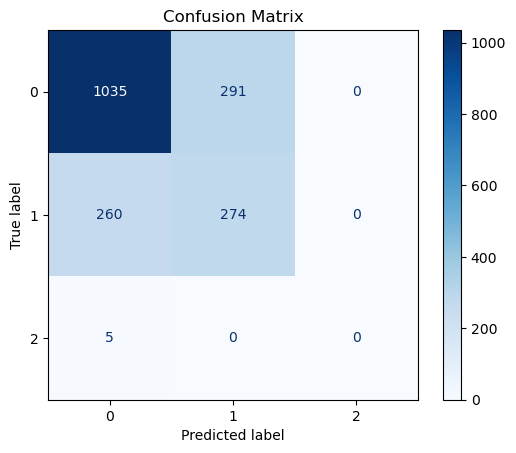

In [ ]:
# compare blood_detector to metadata labels using confusion matrix

# build confusion matrix
cm = confusion_matrix(df.bleed, blood_detected)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# plot
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [46]:
cm

array([[1035,  291,    0],
       [ 260,  274,    0],
       [   5,    0,    0]])